# C3S multimodel anomaly and rank

Include all models.

Using only April for JJASO, as specified in 2026 framework revision

<!-- markdownlint-disable MD013 -->

In [2]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
import calendar

import ocha_stratus as stratus
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter
import numpy as np
import xarray as xr
import statsmodels.api as sm
from dask.diagnostics import ProgressBar
from scipy.stats import skewnorm

from src.datasources import seas5, iri, codab, era5
from src.utils.raster import upsample_dataarray
from src.utils.rp_calc import calculate_groups_rp, calculate_one_group_rp
from src.utils import blob_utils
from src.utils.blob_utils import PROJECT_PREFIX
from src.constants import *

In [4]:
adm2 = codab.load_codab_from_blob(admin_level=2)

In [5]:
adm2_aoi = adm2[adm2["ADM2_PCODE"].isin(AOI_ADM2_PCODES_2026)]

<Axes: >

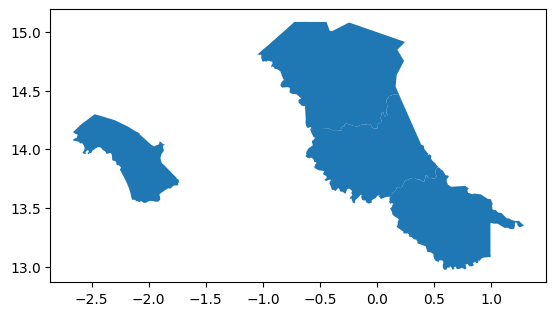

In [6]:
adm2_aoi.plot()

In [91]:
adm2_aoi.to_crs(3857).area.sum()

28499751797.643284

In [92]:
adm2_aoi_old = adm2[adm2["ADM1_PCODE"].isin(AOI_ADM1_PCODES)]

<Axes: >

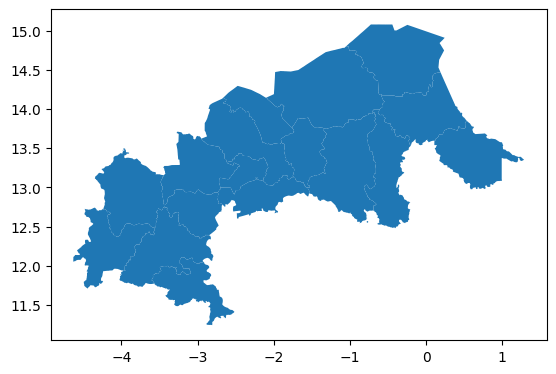

In [93]:
adm2_aoi_old.plot()

In [96]:
adm2_aoi_old.to_crs(3857).area.sum() / adm2_aoi.to_crs(3857).area.sum()

3.9556179066352035

## Process anomaly

In [7]:
new_mo_lt_combos = [{"mo": 4, "lts": [2, 3, 4, 5, 6]}]
new_years = range(1981, 2025 + 1)

In [8]:
da_seas5 = seas5.open_seas5_rasters(
    mo_lt_combos=new_mo_lt_combos, years=new_years
)

  0%|          | 0/45 [00:00<?, ?it/s]

In [9]:
da_seas5

<xarray.DataArray (year: 45, issued_month: 1, lt: 5, y: 451, x: 900)> Size: 365MB
dask.array<concatenate, shape=(45, 1, 5, 451, 900), dtype=float32, chunksize=(1, 1, 1, 451, 900), chunktype=numpy.ndarray>
Coordinates:
  * x             (x) float64 7kB -180.0 -179.6 -179.2 ... 178.8 179.2 179.6
  * y             (y) float64 4kB 90.0 89.6 89.2 88.8 ... -89.2 -89.6 -90.0
    spatial_ref   int64 8B 0
  * lt            (lt) int64 40B 2 3 4 5 6
  * year          (year) int64 360B 1981 1982 1983 1984 ... 2022 2023 2024 2025
  * issued_month  (issued_month) int64 8B 4
Attributes: (12/14)
    AREA_OR_POINT:     Area
    averaging_period:  monthly
    date_issued:       None
    date_valid:        None
    grid_resolution:   0.4
    leadtime_units:    months
    ...                ...
    source:            ECMWF
    units:             mm/day
    version:           None
    scale_factor:      1.0
    add_offset:        0.0
    long_name:         total precipitation

In [10]:
da_seas5_tri = da_seas5.mean(dim="lt")
da_seas5_up = upsample_dataarray(da_seas5_tri)
da_seas5_clip = da_seas5_up.rio.clip(adm2_aoi.geometry)

In [11]:
da_seas5_clip

<xarray.DataArray (year: 45, issued_month: 1, y: 21, x: 38)> Size: 144kB
dask.array<getitem, shape=(45, 1, 21, 38), dtype=float32, chunksize=(1, 1, 21, 38), chunktype=numpy.ndarray>
Coordinates:
  * year          (year) int64 360B 1981 1982 1983 1984 ... 2022 2023 2024 2025
  * issued_month  (issued_month) int64 8B 4
  * x             (x) float64 304B -2.6 -2.5 -2.4 -2.3 -2.2 ... 0.8 0.9 1.0 1.1
  * y             (y) float64 168B 13.0 13.1 13.2 13.3 ... 14.7 14.8 14.9 15.0
    spatial_ref   int64 8B 0

In [12]:
da_seas5_clip

<xarray.DataArray (year: 45, issued_month: 1, y: 21, x: 38)> Size: 144kB
dask.array<getitem, shape=(45, 1, 21, 38), dtype=float32, chunksize=(1, 1, 21, 38), chunktype=numpy.ndarray>
Coordinates:
  * year          (year) int64 360B 1981 1982 1983 1984 ... 2022 2023 2024 2025
  * issued_month  (issued_month) int64 8B 4
  * x             (x) float64 304B -2.6 -2.5 -2.4 -2.3 -2.2 ... 0.8 0.9 1.0 1.1
  * y             (y) float64 168B 13.0 13.1 13.2 13.3 ... 14.7 14.8 14.9 15.0
    spatial_ref   int64 8B 0

(-2.650000000010081,
 1.1499999999897028,
 12.949999999994148,
 15.049999999994029)

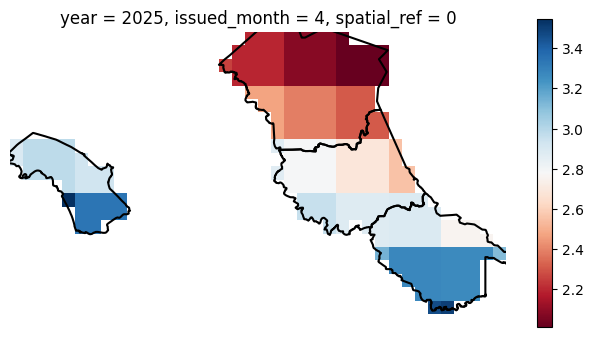

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
da_seas5_clip.isel(year=-1).plot(ax=ax, cmap="RdBu")
adm2_aoi.boundary.plot(ax=ax, color="k")
ax.axis("off")

## Process rank/percentile

In [14]:
da_seas5_clip_yearchunk = da_seas5_clip.chunk({"year": -1})

In [15]:
da_seas5_rank = da_seas5_clip_yearchunk.rank(dim="year", pct=True)

In [16]:
with ProgressBar():
    da_seas5_rank_computed = da_seas5_rank.compute()

[########################################] | 100% Completed | 92.37 s


In [17]:
da_seas5_rank_computed.isel(x=20, y=1, issued_month=0)

<xarray.DataArray (year: 45)> Size: 360B
array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan])
Coordinates:
  * year          (year) int64 360B 1981 1982 1983 1984 ... 2022 2023 2024 2025
    issued_month  int64 8B 4
    x             float64 8B -0.6
    y             float64 8B 13.1
    spatial_ref   int64 8B 0

In [18]:
vmin, vmax = 0, 1

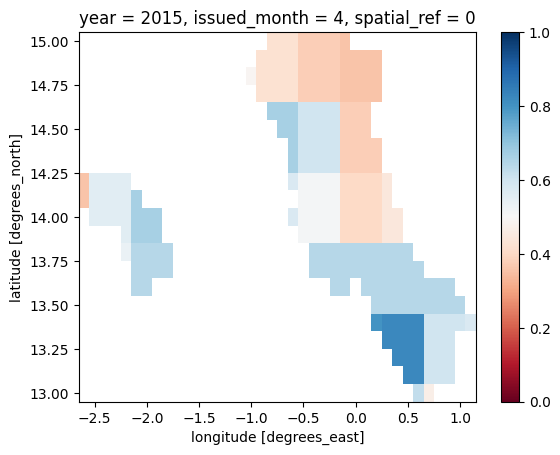

In [19]:
da_seas5_rank_computed.sel(year=2015, issued_month=4).plot(
    cmap="RdBu", vmin=vmin, vmax=vmax
)

In [22]:
da_seas5_rank_q = da_seas5_rank_computed.quantile(q=ORIGINAL_Q, dim=["x", "y"])

In [23]:
with ProgressBar():
    da_seas5_rank_q_computed = da_seas5_rank_q.compute()

In [24]:
df_seas5_rank_q = da_seas5_rank_q_computed.to_dataframe("q")["q"].reset_index()

<Axes: >

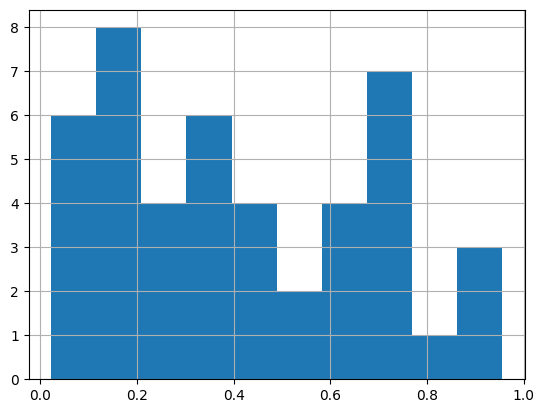

In [25]:
df_seas5_rank_q["q"].hist()

In [26]:
blob_name = f"{blob_utils.PROJECT_PREFIX}/processed/seas5/seas5_rank_q10_2026.parquet"  # noqa
blob_utils.upload_parquet_to_blob(df_seas5_rank_q, blob_name)

### C3S

In [35]:
blob_name = f"{PROJECT_PREFIX}/processed/ensemble/equal_weight_forecast.nc"
data = stratus.load_blob_data(blob_name)

with tempfile.NamedTemporaryFile(suffix=".nc", delete=False) as f:
    f.write(data)
    tmp_path = f.name
try:
    ew = xr.open_dataarray(tmp_path)
finally:
    os.unlink(tmp_path)

In [39]:
ew

<xarray.DataArray 'equal_weight_mean' (year: 24, lat: 8, lon: 10)> Size: 15kB
[1920 values with dtype=float64]
Coordinates:
  * lat          (lat) float64 64B 15.5 14.5 13.5 12.5 11.5 10.5 9.5 8.5
  * lon          (lon) float64 80B -6.5 -5.5 -4.5 -3.5 -2.5 ... -0.5 0.5 1.5 2.5
  * year         (year) int64 192B 1993 1994 1995 1996 ... 2013 2014 2015 2016
    surface      float64 8B ...
    spatial_ref  int64 8B ...

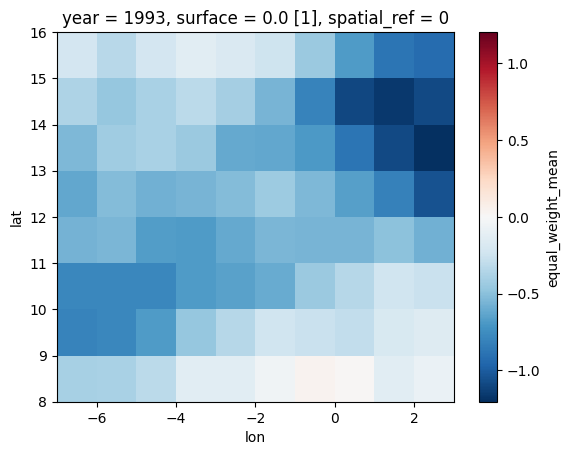

In [38]:
ew.isel(year=0).plot()

In [46]:
ew.rio.set_spatial_dims(x_dim="lon", y_dim="lat")

<xarray.DataArray 'equal_weight_mean' (year: 24, lat: 8, lon: 10)> Size: 15kB
[1920 values with dtype=float64]
Coordinates:
  * lat          (lat) float64 64B 15.5 14.5 13.5 12.5 11.5 10.5 9.5 8.5
  * lon          (lon) float64 80B -6.5 -5.5 -4.5 -3.5 -2.5 ... -0.5 0.5 1.5 2.5
  * year         (year) int64 192B 1993 1994 1995 1996 ... 2013 2014 2015 2016
    surface      float64 8B ...
    spatial_ref  int64 8B ...

In [49]:
ew_up = upsample_dataarray(ew, x_var="lon", y_var="lat")
ew_up = ew_up.rename({"lon": "x", "lat": "y"})
ew_clip = ew_up.rio.clip(adm2_aoi.geometry)

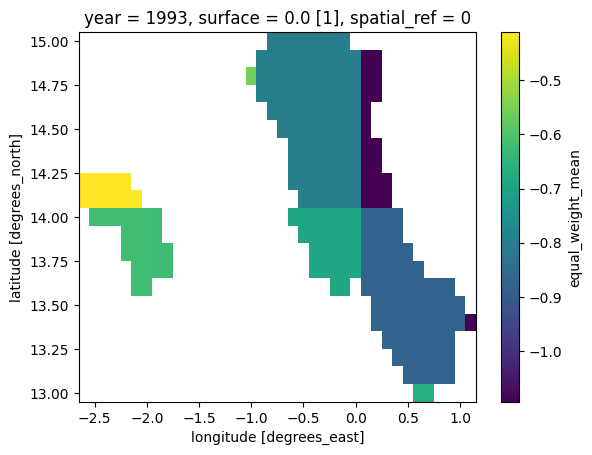

In [51]:
ew_clip.isel(year=0).plot()

In [52]:
ew_clip_yearchunk = ew_clip.chunk({"year": -1})

In [53]:
ew_clip_rank = ew_clip_yearchunk.rank(dim="year", pct=True)

In [54]:
with ProgressBar():
    ew_clip_rank_computed = ew_clip_rank.compute()

[########################################] | 100% Completed | 108.94 ms


In [56]:
ew_clip_rank_computed.isel(x=20, y=1)

<xarray.DataArray 'equal_weight_mean' (year: 24)> Size: 192B
array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])
Coordinates:
  * year         (year) int64 192B 1993 1994 1995 1996 ... 2013 2014 2015 2016
    surface      float64 8B 0.0
    x            float64 8B -0.6
    y            float64 8B 13.1
    spatial_ref  int64 8B 0

In [57]:
vmin, vmax = 0, 1

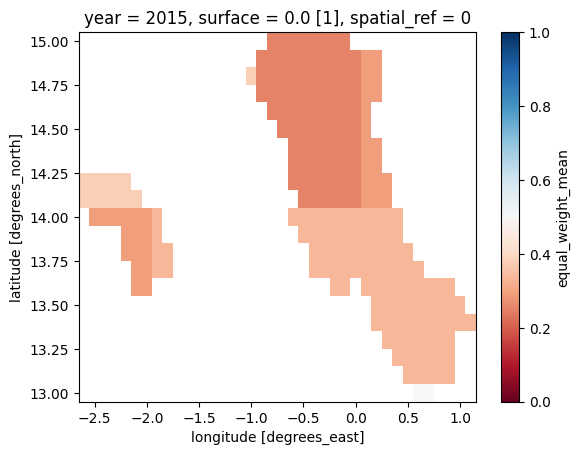

In [59]:
ew_clip_rank_computed.sel(year=2015).plot(cmap="RdBu", vmin=vmin, vmax=vmax)

In [60]:
ew_clip_rank_q = ew_clip_rank_computed.quantile(q=ORIGINAL_Q, dim=["x", "y"])

In [88]:
ew_clip_rank_computed.mean(dim=["x", "y"])

<xarray.DataArray 'equal_weight_mean' (year: 24)> Size: 192B
array([0.09476401, 0.48967552, 0.48838496, 0.16390118, 0.7289823 ,
       0.2704646 , 0.99705015, 0.8949115 , 0.91629794, 0.49594395,
       0.37739676, 0.53023599, 0.43565634, 0.61522861, 0.72382006,
       0.93067847, 0.04516962, 0.7429941 , 0.72806047, 0.8130531 ,
       0.37665929, 0.1675885 , 0.30051622, 0.17256637])
Coordinates:
  * year         (year) int64 192B 1993 1994 1995 1996 ... 2013 2014 2015 2016
    surface      float64 8B 0.0
    spatial_ref  int64 8B 0

In [61]:
with ProgressBar():
    ew_clip_rank_q_computed = ew_clip_rank_q.compute()

In [62]:
df_ew_rank_q = ew_clip_rank_q_computed.to_dataframe("q")["q"].reset_index()

In [63]:
df_ew_rank_q

,year,q
0,1993,0.083333
1,1994,0.291667
2,1995,0.416667
3,1996,0.125000
4,1997,0.666667
5,1998,0.250000
6,1999,1.000000
7,2000,0.833333
8,2001,0.875000
9,2002,0.458333


In [64]:
blob_name = f"{blob_utils.PROJECT_PREFIX}/processed/c3s/c3s_ew_rank_q10_2026.parquet"  # noqa
blob_utils.upload_parquet_to_blob(df_ew_rank_q, blob_name)

### For ERA5

In [109]:
da_era5 = era5.open_era5_rasters(months=[6, 7, 8, 9, 10])

  0%|          | 0/44 [00:00<?, ?it/s]

In [110]:
da_era5

<xarray.DataArray (year: 44, issued_month: 5, y: 721, x: 1440)> Size: 914MB
dask.array<concatenate, shape=(44, 5, 721, 1440), dtype=float32, chunksize=(1, 1, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * x             (x) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * y             (y) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
    spatial_ref   int64 8B 0
  * year          (year) int64 352B 1981 1982 1983 1984 ... 2021 2022 2023 2024
  * issued_month  (issued_month) int64 40B 6 7 8 9 10
Attributes: (12/17)
    AREA_OR_POINT:     Area
    averaging_period:  monthly
    date_issued:       None
    date_valid:        None
    download_date:     2024-09-26
    grid_resolution:   0.25
    ...                ...
    units:             mm/day
    version:           None
    year_issued:       None
    scale_factor:      1.0
    add_offset:        0.0
    long_name:         total precipitation

In [116]:
da_era5_tri = da_era5.mean(dim="issued_month")
da_era5_up = upsample_dataarray(da_era5_tri)
da_era5_clip = da_era5_up.rio.clip(adm2_aoi.geometry)

In [117]:
da_era5_clip_yearchunk = da_era5_clip.chunk({"year": -1})

In [118]:
da_era5_rank = da_era5_clip_yearchunk.rank(dim="year", pct=True)

In [120]:
with ProgressBar():
    da_era5_rank_computed = da_era5_rank.compute()

[########################################] | 100% Completed | 18m 46s


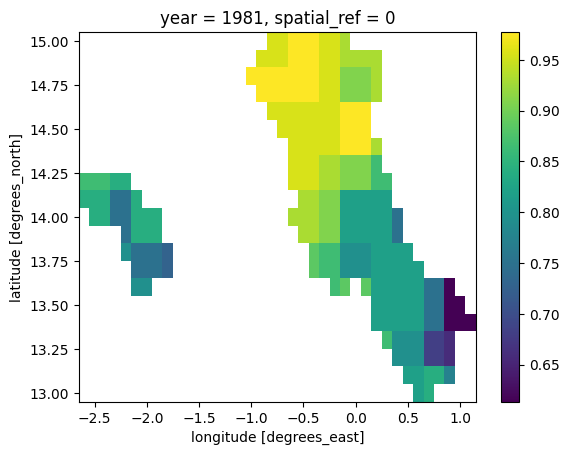

In [121]:
da_era5_rank_computed.isel(year=0).plot()

In [40]:
da_era5_rank_q_computed = da_era5_rank_computed.quantile(
    q=ORIGINAL_Q, dim=["x", "y"]
)

In [41]:
df_era5_rank_q = da_era5_rank_q_computed.to_dataframe("q")["q"].reset_index()

In [42]:
df_era5_rank_q

,year,q
0,1981,0.750000
1,1982,0.181818
2,1983,0.090909
3,1984,0.045455
4,1985,0.636364
5,1986,0.454545
6,1987,0.045455
7,1988,0.659091
8,1989,0.568182
9,1990,0.227273


In [43]:
blob_name = f"{blob_utils.PROJECT_PREFIX}/processed/era5/era5_rank_q10_2026.parquet"  # noqa
blob_utils.upload_parquet_to_blob(df_era5_rank_q, blob_name)

## SEAS5 thresholds

### Loading and processing

In [71]:
blob_name = f"{blob_utils.PROJECT_PREFIX}/processed/seas5/seas5_rank_q10_2026.parquet"  # noqa
df_seas5_rank_q = stratus.load_parquet_from_blob(blob_name)

In [72]:
df_seas5_rank_q = calculate_one_group_rp(df_seas5_rank_q, col_name="q")

In [73]:
blob_name = f"{blob_utils.PROJECT_PREFIX}/processed/era5/era5_rank_q10_2026.parquet"  # noqa
df_era5_rank_q = stratus.load_parquet_from_blob(blob_name)

In [74]:
df_era5_rank_q = calculate_one_group_rp(df_era5_rank_q, col_name="q")

In [75]:
blob_name = f"{blob_utils.PROJECT_PREFIX}/processed/c3s/c3s_ew_rank_q10_2026.parquet"  # noqa
df_ew_rank_q = stratus.load_parquet_from_blob(blob_name)

In [76]:
df_ew_rank_q = calculate_one_group_rp(df_ew_rank_q, col_name="q")

In [77]:
df_seas5_rank_q[df_seas5_rank_q["year"] >= 2000].sort_values("q_rank")

,year,issued_month,q,q_rank,q_rp
24,2005,4,0.133333,9.0,5.111111
35,2016,4,0.133333,9.0,5.111111
28,2009,4,0.133333,9.0,5.111111
38,2019,4,0.188889,12.0,3.833333
39,2020,4,0.200000,13.5,3.407407
26,2007,4,0.222222,16.0,2.875000
33,2014,4,0.311111,19.5,2.358974
37,2018,4,0.355556,22.0,2.090909
34,2015,4,0.377778,23.5,1.957447
21,2002,4,0.422222,26.0,1.769231


In [78]:
df_era5_rank_q[df_era5_rank_q["year"] >= 2000].sort_values("q_rank")

,year,q,q_rank,q_rp
23,2004,0.022727,1.5,30.000000
40,2021,0.022727,1.5,30.000000
42,2023,0.045455,4.5,10.000000
30,2011,0.045455,4.5,10.000000
27,2008,0.113636,8.0,5.625000
33,2014,0.125000,9.0,5.000000
28,2009,0.181818,12.5,3.600000
21,2002,0.181818,12.5,3.600000
25,2006,0.181818,12.5,3.600000
41,2022,0.204545,15.0,3.000000


In [79]:
df_compare = df_era5_rank_q.merge(
    df_seas5_rank_q, on="year", suffixes=("_e", "_s")
).merge(df_ew_rank_q, on="year")

In [83]:
df_compare

,year,q_e,q_rank_e,q_rp_e,issued_month,q_s,q_rank_s,q_rp_s,q,q_rank,q_rp
0,1993,0.227273,17.0,2.647059,4,0.133333,9.0,5.111111,0.083333,2.0,12.500000
1,1994,0.863636,43.0,1.046512,4,0.222222,16.0,2.875000,0.291667,8.5,2.941176
2,1995,0.318182,23.0,1.956522,4,0.422222,26.0,1.769231,0.416667,12.5,2.000000
3,1996,0.136364,10.0,4.500000,4,0.066667,4.0,11.500000,0.125000,4.0,6.250000
4,1997,0.227273,17.0,2.647059,4,0.466667,28.0,1.642857,0.666667,18.0,1.388889
5,1998,0.613636,34.5,1.304348,4,0.311111,19.5,2.358974,0.250000,6.5,3.846154
6,1999,0.931818,44.0,1.022727,4,0.955556,45.0,1.022222,1.000000,24.0,1.041667
7,2000,0.272727,20.0,2.250000,4,0.866667,43.0,1.069767,0.833333,21.0,1.190476
8,2001,0.522727,31.0,1.451613,4,0.888889,44.0,1.045455,0.875000,22.0,1.136364
9,2002,0.181818,12.5,3.600000,4,0.422222,26.0,1.769231,0.458333,14.0,1.785714


In [82]:
df_compare.corr()["q_e"]

year           -0.073791
q_e             1.000000
q_rank_e        0.984539
q_rp_e         -0.503469
issued_month         NaN
q_s             0.257633
q_rank_s        0.244426
q_rp_s         -0.236986
q               0.203586
q_rank          0.199849
q_rp           -0.229640
Name: q_e, dtype: float64

<Axes: xlabel='q_s'>

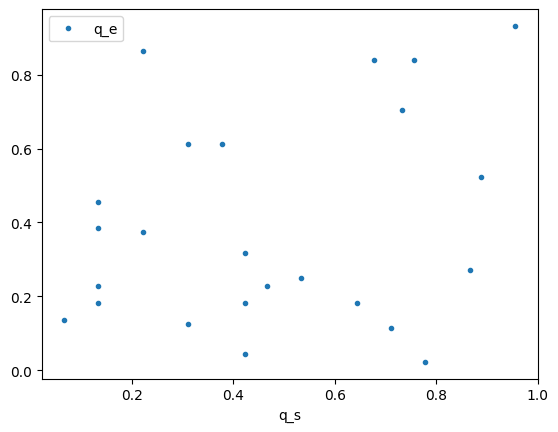

In [98]:
df_compare.plot(x="q_s", y=["q_e"], marker=".", linewidth=0)

<Axes: xlabel='q'>

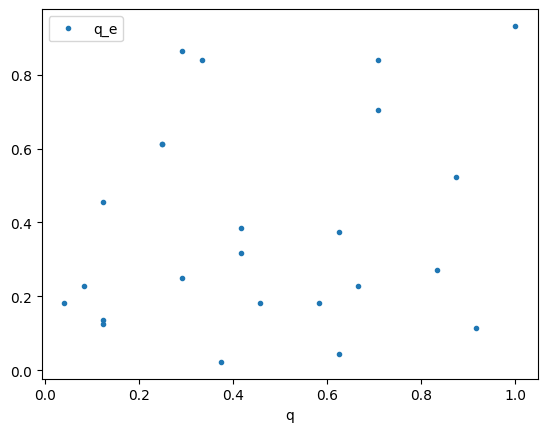

In [99]:
df_compare.plot(x="q", y=["q_e"], marker=".", linewidth=0)

In [58]:
df_compare.corr()

,year,q_e,q_rank_e,q_rp_e,issued_month,q_s,q_rank_s,q_rp_s
year,1.000000,-0.068217,-0.065049,0.137537,NaN,0.342822,0.352174,-0.384108
q_e,-0.068217,1.000000,0.984622,-0.562863,NaN,0.159377,0.148386,-0.081487
q_rank_e,-0.065049,0.984622,1.000000,-0.642937,NaN,0.100792,0.093377,-0.074264
q_rp_e,0.137537,-0.562863,-0.642937,1.000000,NaN,0.196974,0.208402,-0.051283
issued_month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
q_s,0.342822,0.159377,0.100792,0.196974,NaN,1.000000,0.991134,-0.579276
q_rank_s,0.352174,0.148386,0.093377,0.208402,NaN,0.991134,1.000000,-0.638375
q_rp_s,-0.384108,-0.081487,-0.074264,-0.051283,NaN,-0.579276,-0.638375,1.000000


<Axes: xlabel='year'>

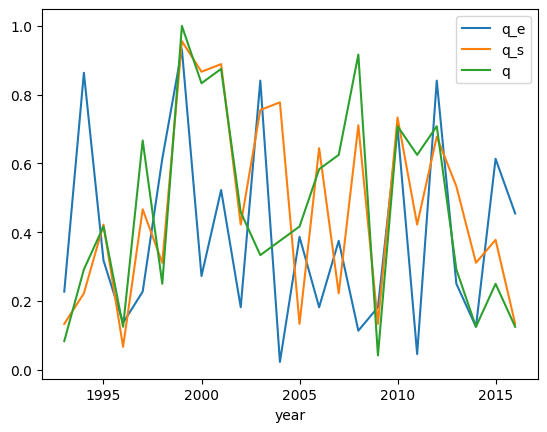

In [100]:
df_compare.plot(x="year", y=["q_e", "q_s", "q"])

In [59]:
df_seas5_rank_q_recent = df_seas5_rank_q[
    df_seas5_rank_q["year"] >= 2000
].copy()

In [60]:
df_seas5_rank_q_recent = calculate_one_group_rp(
    df_seas5_rank_q_recent, col_name="q"
)

In [61]:
df_seas5_rank_q_recent.sort_values("q_rank")

,year,issued_month,q,q_rank,q_rp
24,2005,4,0.133333,2.0,13.500000
35,2016,4,0.133333,2.0,13.500000
28,2009,4,0.133333,2.0,13.500000
38,2019,4,0.188889,4.0,6.750000
39,2020,4,0.200000,5.0,5.400000
26,2007,4,0.222222,6.0,4.500000
33,2014,4,0.311111,7.0,3.857143
37,2018,4,0.355556,8.0,3.375000
34,2015,4,0.377778,9.0,3.000000
21,2002,4,0.422222,10.5,2.571429


In [134]:
df_seas5_median = (
    da_seas5_rank_computed.median(dim=["x", "y"])
    .squeeze(drop=True)
    .to_dataframe("median_s")["median_s"]
    .reset_index()
)
df_era5_median = (
    da_era5_rank_computed.median(dim=["x", "y"])
    .squeeze(drop=True)
    .to_dataframe("median_e")["median_e"]
    .reset_index()
)
df_ew_median = (
    ew_clip_rank_computed.median(dim=["x", "y"])
    .squeeze(drop=True)
    .to_dataframe("median_c")["median_c"]
    .reset_index()
)

In [135]:
df_comp_median = df_seas5_median.merge(df_era5_median).merge(df_ew_median)

In [137]:
df_comp_median.corr()

,year,median_s,median_e,median_c
year,1.000000,0.146886,-0.145928,-0.060004
median_s,0.146886,1.000000,0.167270,0.724632
median_e,-0.145928,0.167270,1.000000,0.198402
median_c,-0.060004,0.724632,0.198402,1.000000


<Axes: xlabel='median_e'>

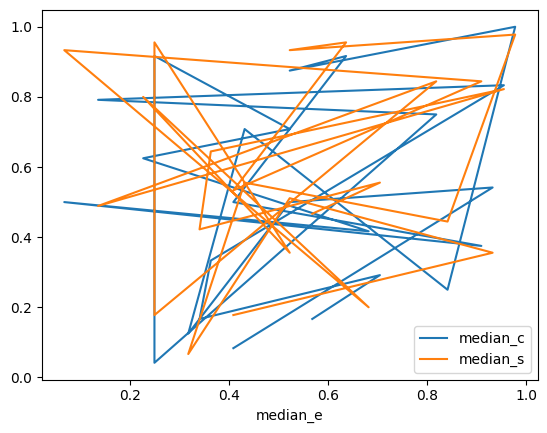

In [142]:
df_comp_median.plot(x="median_e", y=["median_c", "median_s"])

In [143]:
df_comp_median.sort_values("median_c")

,year,median_s,median_e,median_c
16,2009,0.177778,0.250000,0.041667
0,1993,0.177778,0.409091,0.083333
3,1996,0.066667,0.318182,0.125000
21,2014,0.422222,0.340909,0.166667
23,2016,0.466667,0.568182,0.166667
5,1998,0.444444,0.840909,0.250000
22,2015,0.555556,0.704545,0.291667
20,2013,0.644444,0.363636,0.333333
10,2003,0.844444,0.909091,0.375000
12,2005,0.200000,0.681818,0.416667


In [146]:
(len(df_comp_median) + 1) / 3

8.333333333333334

In [138]:
df_seas5_mean = (
    da_seas5_rank_computed.mean(dim=["x", "y"])
    .squeeze(drop=True)
    .to_dataframe("mean_s")["mean_s"]
    .reset_index()
)
df_era5_mean = (
    da_era5_rank_computed.mean(dim=["x", "y"])
    .squeeze(drop=True)
    .to_dataframe("mean_e")["mean_e"]
    .reset_index()
)
df_ew_mean = (
    ew_clip_rank_computed.mean(dim=["x", "y"])
    .squeeze(drop=True)
    .to_dataframe("mean_c")["mean_c"]
    .reset_index()
)

In [139]:
df_comp_mean = df_seas5_mean.merge(df_era5_mean).merge(df_ew_mean)

In [140]:
df_comp_mean.corr()

,year,mean_s,mean_e,mean_c
year,1.000000,0.107966,-0.125099,-0.064448
mean_s,0.107966,1.000000,0.208358,0.750635
mean_e,-0.125099,0.208358,1.000000,0.203461
mean_c,-0.064448,0.750635,0.203461,1.000000


In [1]:
(2025-2001+1+1)/4

6.5

In [12]:
4/(2025-2001+1+1)

0.15384615384615385

In [13]:
5/(2025-2001+1+1)

0.19230769230769232

In [2]:
(2025-2001+1+1)/5

5.2

In [3]:
(2025-2001+1+1)/6

4.333333333333333

In [4]:
(2025-2001+1+1)/7

3.7142857142857144

In [65]:
(2025 - 2001 + 1 + 1) / 8

3.25

In [68]:
8 / (2025 - 2001 + 1 + 1)

0.3076923076923077

In [69]:
8 / (2025 - 2001 + 1 + 1) * 8

2.4615384615384617

Quick comparison of the three metrics shows high correlation as expected.

Seems like (and I have no clue how significant this is) Z-score is a bit closer to anomaly than rank.
And both rank and anomaly are closer to Z-score than to each other.

In [9]:
for mo, group in df_seas5_compare.groupby("issued_month"):
    display(group[[x for x in df_seas5_compare.columns if "q_" in x]].corr())

,q_anomaly,q_zscore,q_rank
q_anomaly,1.000000,0.985075,0.960259
q_zscore,0.985075,1.000000,0.972029
q_rank,0.960259,0.972029,1.000000


,q_anomaly,q_zscore,q_rank
q_anomaly,1.000000,0.993184,0.962211
q_zscore,0.993184,1.000000,0.983557
q_rank,0.962211,0.983557,1.000000


<Axes: xlabel='q_anomaly'>

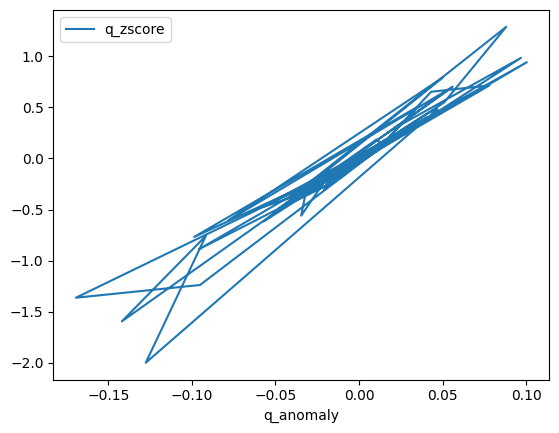

In [10]:
df_seas5_compare.plot(x="q_anomaly", y="q_zscore")

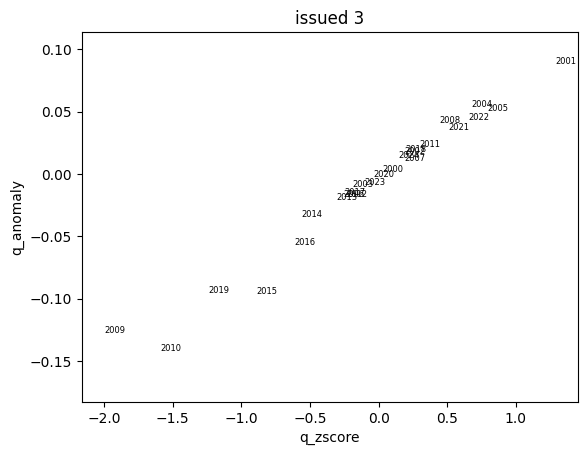

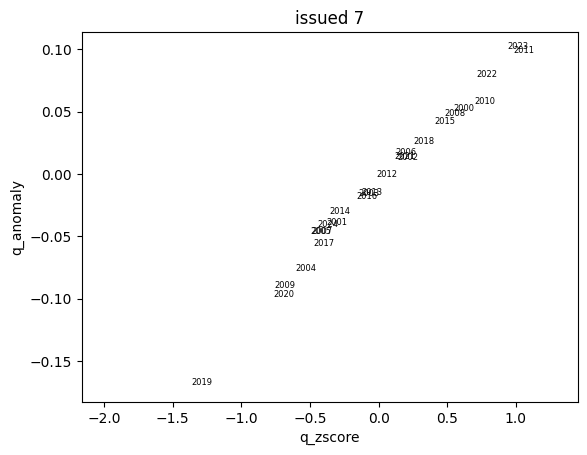

In [11]:
x_var, y_var = "q_zscore", "q_anomaly"
for mo, group in df_seas5_compare.groupby("issued_month"):
    fig, ax = plt.subplots()
    df_seas5_compare.plot(x=x_var, y=y_var, ax=ax, linewidth=0, legend=False)
    for year, row in group.set_index("year").iterrows():
        ax.annotate(year, (row[x_var], row[y_var]), fontsize=6)
    ax.set_ylabel(y_var)
    ax.set_title(f"issued {mo}")

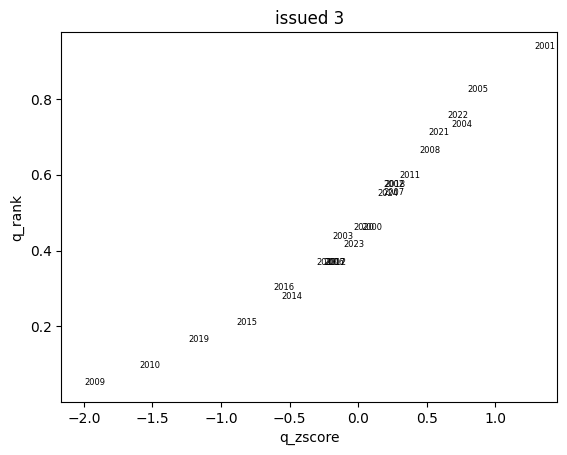

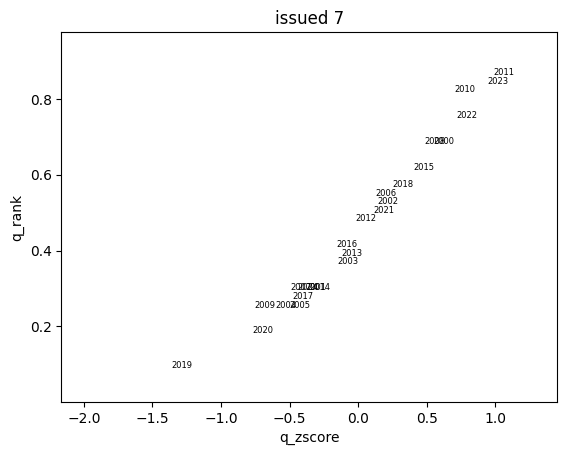

In [12]:
x_var, y_var = "q_zscore", "q_rank"
for mo, group in df_seas5_compare.groupby("issued_month"):
    fig, ax = plt.subplots()
    df_seas5_compare.plot(x=x_var, y=y_var, ax=ax, linewidth=0, legend=False)
    for year, row in group.set_index("year").iterrows():
        ax.annotate(year, (row[x_var], row[y_var]), fontsize=6)
    ax.set_ylabel(y_var)
    ax.set_title(f"issued {mo}")

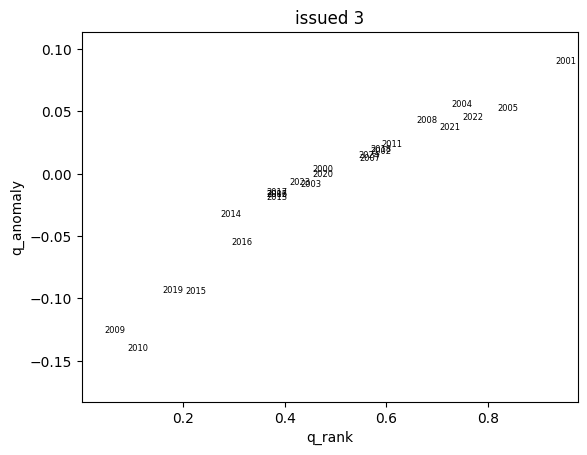

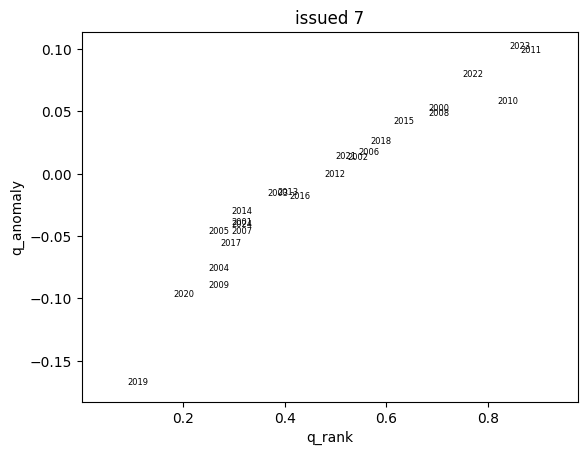

In [13]:
x_var, y_var = "q_rank", "q_anomaly"
for mo, group in df_seas5_compare.groupby("issued_month"):
    fig, ax = plt.subplots()
    df_seas5_compare.plot(x=x_var, y=y_var, ax=ax, linewidth=0, legend=False)
    for year, row in group.set_index("year").iterrows():
        ax.annotate(year, (row[x_var], row[y_var]), fontsize=6)
    ax.set_ylabel(y_var)
    ax.set_title(f"issued {mo}")

Next cell proceeds with rest of calculations using rank.

This is selected purely because it can argued that it's closest in meaning to the original trigger (tercile forecast), since the output is a percentile.
I think, this also fits best with the overall intent of the framework- to capture the worst historical years. The cleanest way to do that in my mind is to just take the historical rank (in percentile form), and avoids the issues of having to make any assumptions about the distribution.

In [14]:
df_seas5 = df_seas5_rank.copy()

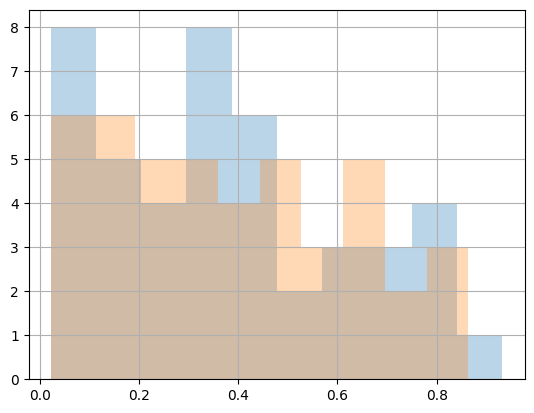

In [15]:
# just check the histogram to see that it's sensible
for issued_month, group in df_seas5.groupby("issued_month"):
    group["q"].hist(alpha=0.3)

In [16]:
df_seas5 = calculate_groups_rp(df_seas5, ["issued_month"])

In [17]:
df_pivot_rps = df_seas5.pivot(
    index="year", columns="issued_month", values="q_rp"
).reset_index()
df_pivot_rps = df_pivot_rps.rename(columns={x: f"issued_{x}" for x in [3, 7]})

In [18]:
dicts = []
min_individual_rp = 2

rp_list = df_seas5["q_rp"].unique()
rp_list = rp_list[rp_list >= min_individual_rp]
for rp_3 in rp_list:
    for rp_7 in rp_list:
        dff = df_pivot_rps[
            (df_pivot_rps["issued_3"] >= rp_3)
            | (df_pivot_rps["issued_7"] >= rp_7)
        ]
        dicts.append(
            {
                "rp_3": rp_3,
                "rp_7": rp_7,
                "rp_overall": (df_seas5["year"].nunique() + 1)
                / dff["year"].nunique(),
            }
        )
df_rps = pd.DataFrame(dicts)

### Check trend

In [19]:
df_pivot = df_seas5.pivot(
    index="year", columns="issued_month", values="q"
).reset_index()
df_pivot = df_pivot.rename(columns={x: f"issued_{x}" for x in [3, 7]})

<Axes: xlabel='year'>

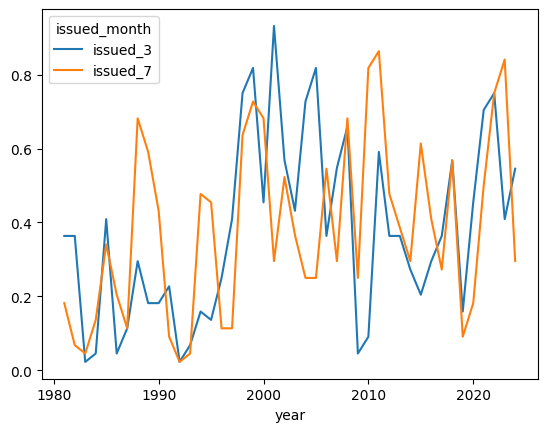

In [20]:
df_pivot.plot(x="year", y=["issued_3", "issued_7"])

In [21]:
for issued_month in [3, 7]:
    X = sm.add_constant(df_pivot.index)
    model = sm.OLS(df_pivot[f"issued_{issued_month}"], X).fit()
    print(f"issued month {issued_month}")
    print(model.summary())

issued month 3
                            OLS Regression Results                            
Dep. Variable:               issued_3   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.125
Method:                 Least Squares   F-statistic:                     7.138
Date:                Tue, 11 Mar 2025   Prob (F-statistic):             0.0107
Time:                        10:33:12   Log-Likelihood:                 3.0037
No. Observations:                  44   AIC:                            -2.007
Df Residuals:                      42   BIC:                             1.561
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2183      0.069     

Same as for absolute values -
as a crude check, we see that the confidence intervals for the slope are
positive. So we can try to filter to more recent years to hopefully
make it trendless.

In [22]:
min_year = 2001
df_pivot_recent = df_pivot[df_pivot["year"] >= min_year]

<Axes: xlabel='year'>

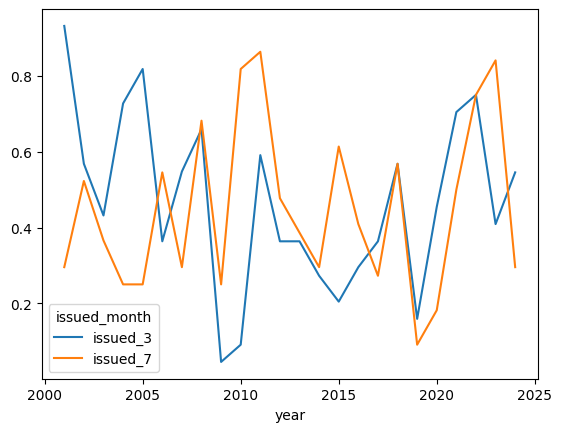

In [23]:
df_pivot_recent.plot(x="year", y=["issued_3", "issued_7"])

In [24]:
for issued_month in [3, 7]:
    X = sm.add_constant(df_pivot_recent.index)
    model = sm.OLS(df_pivot_recent[f"issued_{issued_month}"], X).fit()
    print(f"issued month {issued_month}")
    print(model.summary())

issued month 3
                            OLS Regression Results                            
Dep. Variable:               issued_3   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.012
Date:                Tue, 11 Mar 2025   Prob (F-statistic):              0.325
Time:                        10:33:13   Log-Likelihood:                 2.1718
No. Observations:                  24   AIC:                           -0.3435
Df Residuals:                      22   BIC:                             2.013
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6836      0.220     

Confidence intervals of slope span 0 now, so we're good.

In [25]:
df_pivot_recent

issued_month,year,issued_3,issued_7
20,2001,0.931818,0.295455
21,2002,0.568182,0.522727
22,2003,0.431818,0.365909
23,2004,0.727273,0.250000
24,2005,0.818182,0.250000
25,2006,0.363636,0.545455
26,2007,0.547727,0.295455
27,2008,0.659091,0.681818
28,2009,0.045455,0.250000
29,2010,0.090909,0.818182


### Plot historical activations

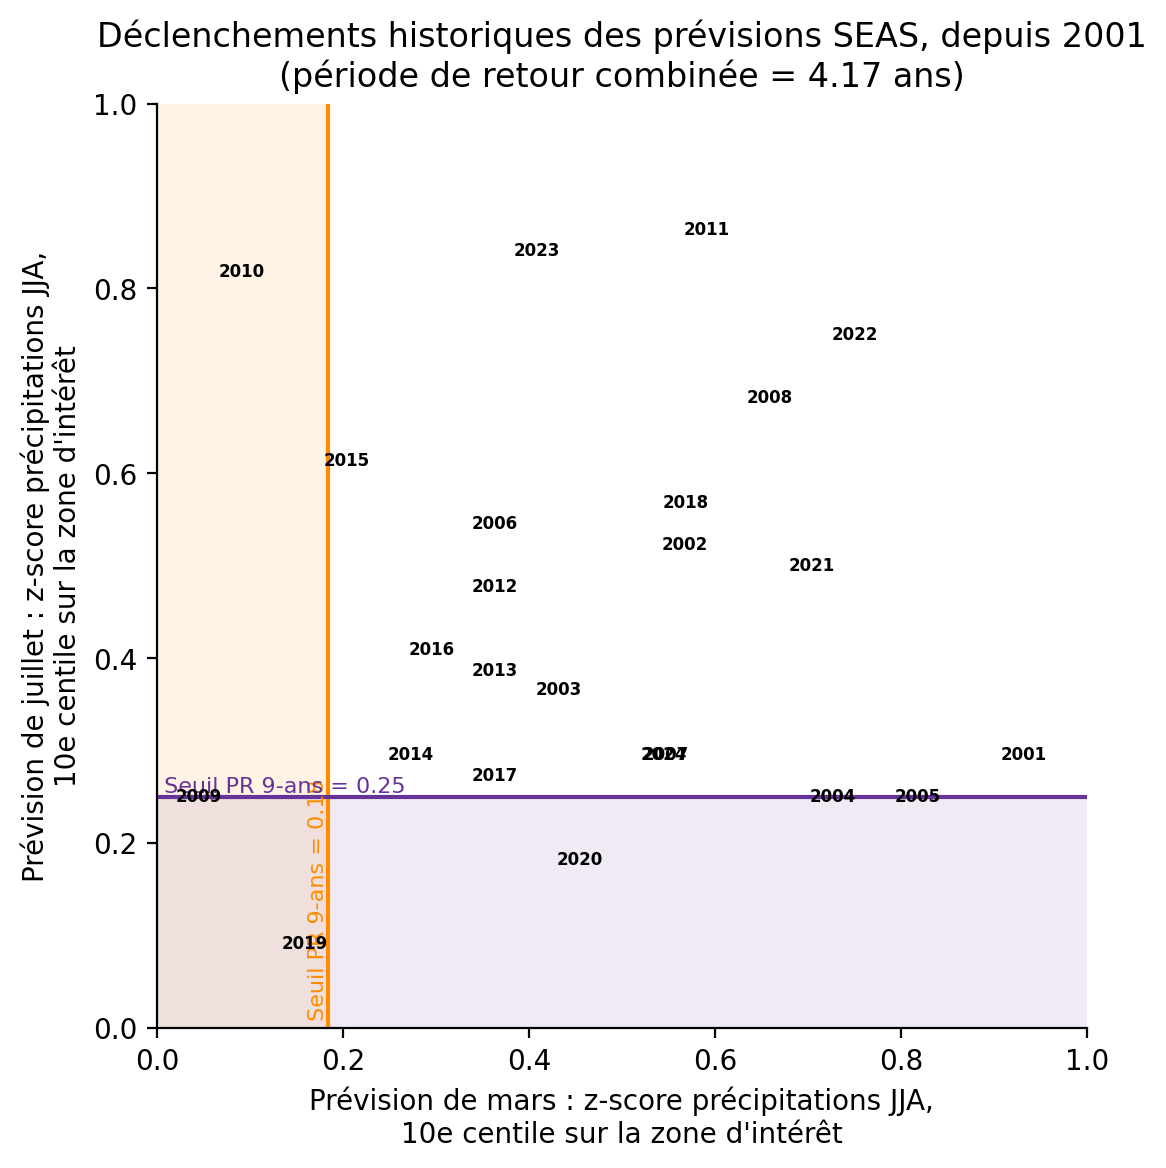

In [26]:
rp_individual_seas5 = 9

thresh_3 = df_pivot_recent["issued_3"].quantile(1 / rp_individual_seas5)
thresh_7 = df_pivot_recent["issued_7"].quantile(1 / rp_individual_seas5)

rp_overall = (len(df_pivot_recent) + 1) / df_pivot_recent[
    (df_pivot_recent["issued_3"] <= thresh_3)
    | (df_pivot_recent["issued_7"] <= thresh_7)
]["year"].nunique()

fig, ax = plt.subplots(dpi=200, figsize=(6, 6))

# min_val = -0.19
# max_val = 0.11
min_val, max_val = 0, 1
xmin = min_val
xmax = max_val
ymin = min_val
ymax = max_val

alpha = 0.1

color_3 = "darkorange"
ax.axvline(thresh_3, color=color_3)
ax.axvspan(xmin=xmin, xmax=thresh_3, facecolor=color_3, alpha=alpha)
ax.annotate(
    f" Seuil PR {rp_individual_seas5}-ans = {thresh_3:.2f}",
    (thresh_3, ymin),
    rotation=90,
    ha="right",
    va="bottom",
    fontsize=8,
    color=color_3,
)

color_7 = "rebeccapurple"
ax.axhline(thresh_7, color=color_7)
ax.axhspan(ymin=ymin, ymax=thresh_7, facecolor=color_7, alpha=alpha)
ax.annotate(
    f" Seuil PR {rp_individual_seas5}-ans = {thresh_7:.2f}",
    (xmin, thresh_7),
    ha="left",
    va="bottom",
    fontsize=8,
    color=color_7,
)

for year, row in df_pivot_recent.set_index("year").iterrows():
    ax.annotate(
        year,
        (row["issued_3"], row["issued_7"]),
        va="center",
        ha="center",
        fontsize=6,
        fontweight="bold",
    )

ax.set_xlim((xmin, xmax))
ax.set_ylim((ymin, ymax))

ax.set_xlabel(
    "Prévision de mars : z-score précipitations JJA,\n"
    "10e centile sur la zone d'intérêt"
)
ax.set_ylabel(
    "Prévision de juillet : z-score précipitations JJA,\n"
    "10e centile sur la zone d'intérêt"
)
ax.set_title(
    f"Déclenchements historiques des prévisions SEAS, depuis {min_year}\n"
    f"(période de retour combinée = {rp_overall:.2f} ans)"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

Fixing thresholds based on proposed values for framework. We are fixing the same value for both months for a couple reasons:

- We can't really say whether the spatial quantile values we're plotting have a different distribution from issue month to issue month, so it doesn't really make sense to fix the threshold independently for each one.
- Having the same threshold for each month is just easier to remember and easier to explain.
- Also, conveniently, the threshold that corresponds to the requested forecast RP (around 6 years combined), is 20th, which is the lower quintile

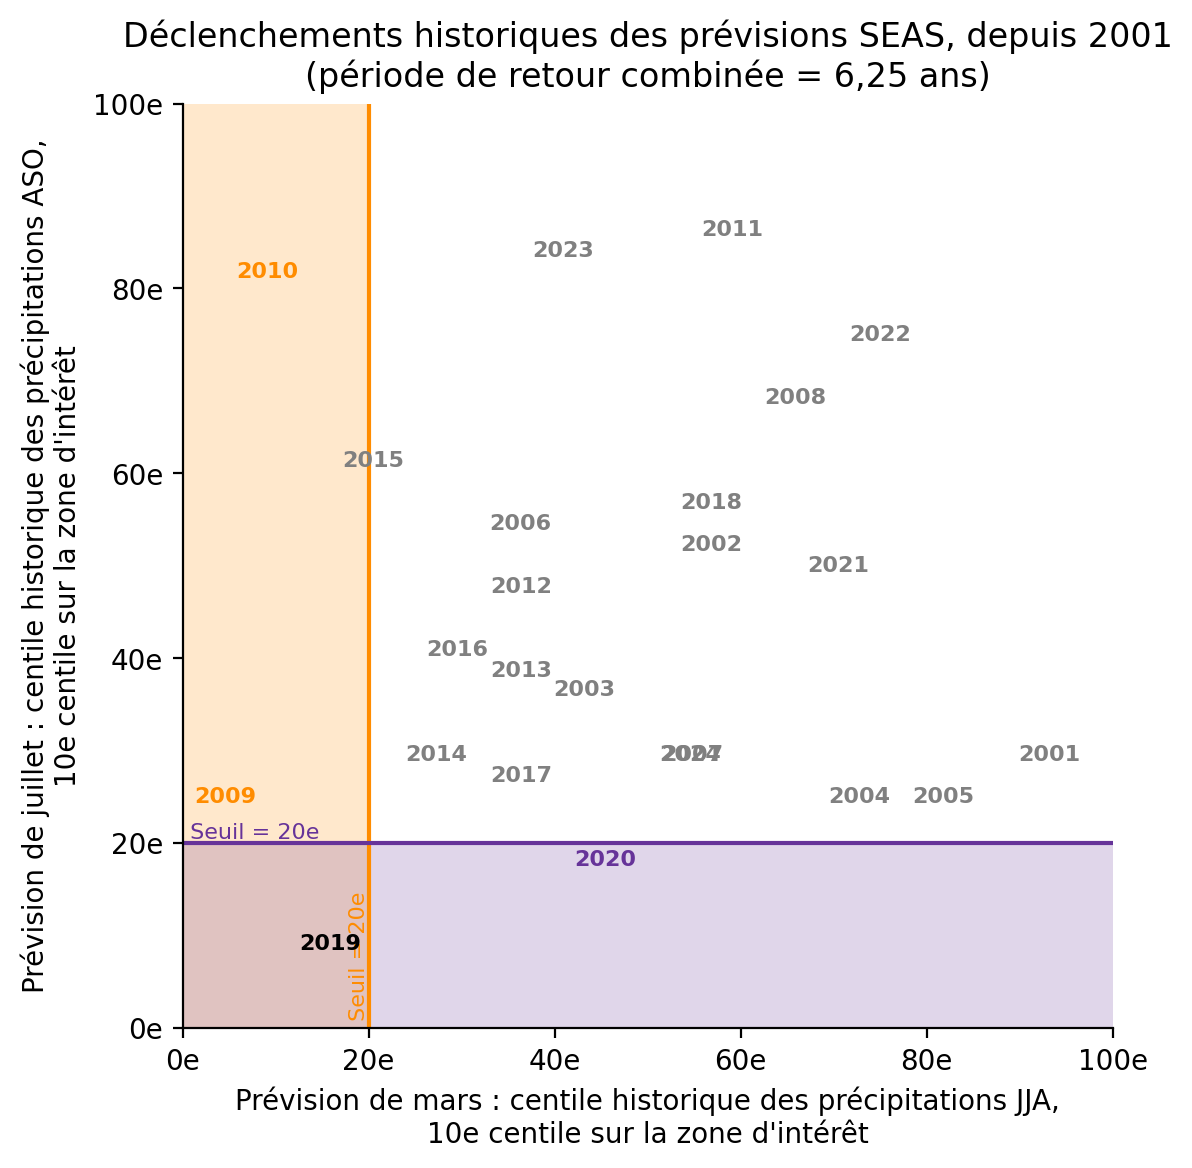

In [34]:
# thresh_3 = -0.9
# thresh_7 = -0.66
thresh_3 = 0.2
thresh_7 = thresh_3


rp_overall = (len(df_pivot_recent) + 1) / df_pivot_recent[
    (df_pivot_recent["issued_3"] <= thresh_3)
    | (df_pivot_recent["issued_7"] <= thresh_7)
]["year"].nunique()

fig, ax = plt.subplots(dpi=200, figsize=(6, 6))

# min_val = -2.2
# max_val = 1.5
min_val, max_val = 0, 1
xmin = min_val
xmax = max_val
ymin = min_val
ymax = max_val

alpha = 0.2

color_3 = "darkorange"
color_7 = "rebeccapurple"

ax.axvline(thresh_3, color=color_3)
ax.axvspan(xmin=xmin, xmax=thresh_3, facecolor=color_3, alpha=alpha)
ax.annotate(
    f" Seuil = {thresh_3* 100:.0f}e",
    (thresh_3, ymin),
    rotation=90,
    ha="right",
    va="bottom",
    fontsize=8,
    color=color_3,
)

ax.axhline(thresh_7, color=color_7)
ax.axhspan(ymin=ymin, ymax=thresh_7, facecolor=color_7, alpha=alpha)
ax.annotate(
    f" Seuil = {thresh_7* 100:.0f}e",
    (xmin, thresh_7),
    ha="left",
    va="bottom",
    fontsize=8,
    color=color_7,
)

for year, row in df_pivot_recent.set_index("year").iterrows():
    if (row["issued_3"] < thresh_3) & (row["issued_7"] < thresh_7):
        color = "black"
    elif row["issued_3"] < thresh_3:
        color = color_3
    elif row["issued_7"] < thresh_7:
        color = color_7
    else:
        color = "grey"
    ax.annotate(
        year,
        (row["issued_3"], row["issued_7"]),
        va="center",
        ha="center",
        fontsize=8,
        fontweight="bold",
        color=color,
    )

ax.set_xlim((xmin, xmax))
ax.set_ylim((ymin, ymax))


# Custom formatter for the ticks
def custom_percentage_formatter(x, pos):
    return f"{x * 100:.0f}e"  # Multiplies by 100 and appends 'e'


ax.xaxis.set_major_formatter(FuncFormatter(custom_percentage_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(custom_percentage_formatter))

ax.set_xlabel(
    "Prévision de mars : centile historique des précipitations JJA,\n"
    "10e centile sur la zone d'intérêt"
)
ax.set_ylabel(
    "Prévision de juillet : centile historique des précipitations ASO,\n"
    "10e centile sur la zone d'intérêt"
)
ax.set_title(
    f"Déclenchements historiques des prévisions SEAS, depuis {min_year}\n"
    f"(période de retour combinée = {rp_overall:.2f} ans)".replace(".", ",")
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

In [45]:
(2024 - 2001 + 1) * 2

48

In [48]:
((2024 - 2001 + 1) * 2 + 1) / 5

9.8